# Regressing the earlier static response out of the last frame

Compares two ways of removing an earlier static response (the 2000 ms or 2250 ms movie frame shown as an image) from the last-frame static response:

- **pooled** — reference from `summary_figs_report.ipynb`: one OLS map shared by every timepoint and stimulus, fitted in-sample.
- **timepoint** — one ridge model per static timepoint (stimuli are the samples); residuals are out-of-fold when `cfg.timepoint_cv_type = 'kf'`.
- **window** — window-to-window: both responses are first averaged inside each static window, then one ridge model per window predicts the last-frame window pattern from the earlier response's pattern in the same window. It only exists at window level, so it appears in the window analyses only.

Then, instead of using the whole static timeseries as a model, the static response averaged in 10 consecutive windows (50–100, 100–150, … ms) is used as a model RDM, as if each window were a DNN layer, and its RSA timecourse with the movie response is computed before and after regression.

In [32]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import yaml

ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')
PROJECT_ROOT = Path('../..').resolve()
with open(PROJECT_ROOT / 'config.yaml', 'r') as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]['paths']
sys.path.extend([paths['src_path'], paths['useful_stuff_path']])

from project_specific_utils import (
    compute_rdm_timeseries, cross_temporal_similarity, depth_latency_score,
    load_natraster, match_timed_static_movie_rasters,
    pooled_static_regress_out, summarize_layer_timing,
    timepoint_static_regress_out, window_model_timecourses, window_patterns,
    window_static_regress_out,
)
from useful_stuff.general_utils import TimeSeries

In [105]:
@dataclass
class Cfg:
    img_exp_name: str = "baby1_260718to27"#"red_20260726to0925" #"paul_20260901to0923" # #
    vid_exp_name: str = "baby1_260716to24"#"red_20260720to0927" # "paul_20260831to0927" #
    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None = None #(1, 64) # 
    use_reliable_channels: bool = True
    reliable_channels_key: str | None = None #"red_20260726to0923" #"paul_20260901to0923" #
    new_fs: float = 100
    signal_RDM_metric: str = 'cosine_cnt'
    RSA_metric: str = 'correlation'
    last_frame_onset_ms: float = 2500
    residual_conditions: tuple[str, ...] = ('2000ms', '2250ms')
    residual_delay_embedding_lags: tuple[int, int] = (-1, 1)
    # Reference (pooled) regression, as in summary_figs_report.
    pooled_regression_type: str = 'lr'
    # Per-timepoint ridge regression.
    timepoint_regression_type: str = 'ridge'
    timepoint_alphas: tuple[float, ...] = (1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4, 1e5)
    timepoint_cv_type: str = 'kf'  # 'kf' out-of-fold residuals, 'same' in-sample
    timepoint_n_splits: int = 5
    # Window-to-window ridge regression (one model per static window).
    window_regression_type: str = 'ridge'
    window_alphas: tuple[float, ...] = (1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4, 1e5)
    window_cv_type: str = 'kf'  # 'kf' out-of-fold residuals, 'same' in-sample
    window_n_splits: int = 5
    # Static windows used as "layers": [start, start + width) ms from image onset.
    window_first_start_ms: float = 100
    window_width_ms: float = 50
    # Gap skipped between the end of one window and the start of the next (0 = contiguous).
    window_gap_ms: float = 0
    n_windows: int = 10
    # Latency summaries of the window timecourses (absolute movie time, end-exclusive).
    timing_window_ms: tuple[float, float] = (2300, 2700)
    # Only positive-mass above this RSA value carries centroid weight.
    centroid_cutoff: float = 0.0
    # Windows whose smoothed peak RSA (inside timing_window_ms) does not exceed
    # this value are dropped from BOTH centroid and peak latency correlations.
    peak_cutoff: float = 0.01
    smoothing: float = 3
    plot_window_ms: tuple[float, float] = (2000, 3500)
    linewidth: float = 2


cfg = Cfg()
# Readable plot titles for every (method, condition) key used below.
method_descriptions = {
    'raw': 'nothing regressed out',
    'pooled': 'pooled OLS, all timepoints',
    'timepoint': 'ridge per timepoint',
    'window': 'window-to-window ridge',
}
def version_title(key):
    method, condition = key
    if method == 'raw':
        return f'Last frame, {method_descriptions[method]}'
    # end if method == 'raw'
    return f'Last frame − {condition} frame response ({method_descriptions[method]})'
# EOF
# Consecutive windows start (width + gap) ms apart, e.g. width 50, gap 25:
# 100-150, 175-225, 250-300, ...
window_step_ms = cfg.window_width_ms + cfg.window_gap_ms
windows_ms = [
    (cfg.window_first_start_ms + index * window_step_ms,
     cfg.window_first_start_ms + index * window_step_ms + cfg.window_width_ms)
    for index in range(cfg.n_windows)
]
print(f'Static windows (ms): {windows_ms}')

Static windows (ms): [(100, 150), (150, 200), (200, 250), (250, 300), (300, 350), (350, 400), (400, 450), (450, 500), (500, 550), (550, 600)]


In [106]:
# Load both sessions with the same channel selection as summary_figs_report.
data_dir = Path(paths['data_path']) / 'data'
load_kwargs = dict(
    good_channels=cfg.good_channels,
    reliable_channels_config=(
        PROJECT_ROOT / 'reliable_channels.yaml' if cfg.use_reliable_channels else None
    ),
    reliable_channels_key=(
        (cfg.reliable_channels_key or cfg.img_exp_name)
        if cfg.use_reliable_channels else None
    ),
    return_channel_numbers=True,
)
loaded_vid_rasters, vid_stimulus_names, vid_channel_numbers = load_natraster(
    data_dir / f'{cfg.vid_exp_name}_natraster_vid.mat', **load_kwargs,
)
loaded_img_rasters, img_stimulus_names, img_channel_numbers = load_natraster(
    data_dir / f'{cfg.img_exp_name}_natraster_img.mat', **load_kwargs,
)
if not np.array_equal(img_channel_numbers, vid_channel_numbers):
    raise ValueError('Image and movie sessions retained different channels.')
# end if channel numbers differ

(
    image_rasters, video_rasters, image_2000ms_rasters, image_2250ms_rasters,
    shared_stimuli, aligned_names,
) = match_timed_static_movie_rasters(
    loaded_img_rasters, img_stimulus_names,
    loaded_vid_rasters, vid_stimulus_names,
)
print(f'{len(shared_stimuli)} stimuli, {image_rasters.shape[0]} channels')

# channels x time x stimuli, resampled from 1000 Hz to the analysis rate.
image_ts = TimeSeries(image_rasters, fs=1000)
video_ts = TimeSeries(video_rasters, fs=1000)
delayed_static_by_condition = {
    '2000ms': TimeSeries(image_2000ms_rasters, fs=1000),
    '2250ms': TimeSeries(image_2250ms_rasters, fs=1000),
}
for neural_ts in (image_ts, video_ts, *delayed_static_by_condition.values()):
    neural_ts.resample(cfg.new_fs)
# end for neural_ts

static_time_ms = np.arange(len(image_ts)) * 1000 / image_ts.get_fs()
dynamic_time_ms = np.arange(len(video_ts)) * 1000 / video_ts.get_fs()
# movie time x stimulus pairs, shared by every comparison below.
dynamic_rdms = compute_rdm_timeseries(video_ts.get_array(), cfg.signal_RDM_metric)

100 stimuli, 30 channels


## Residuals: pooled (reference) vs one ridge model per timepoint

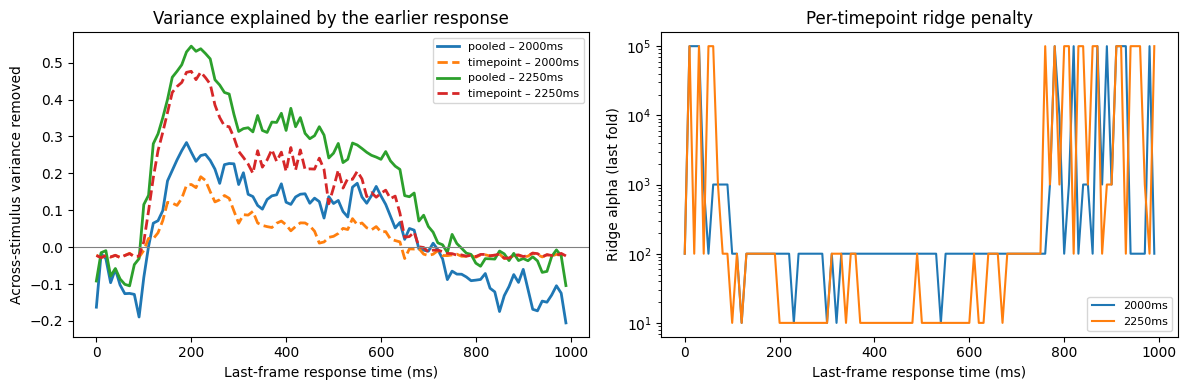

In [107]:
# Keys are (method, condition); 'raw' is the unregressed last-frame response.
static_versions = {('raw', 'none'): image_ts}
variance_explained = {}
timepoint_alphas = {}

for delayed_condition in cfg.residual_conditions:
    delayed_ts = delayed_static_by_condition[delayed_condition]

    residual_ts, variance_explained[('pooled', delayed_condition)] = (
        pooled_static_regress_out(
            delayed_ts, image_ts,
            delay_embedding_lags=cfg.residual_delay_embedding_lags,
            regression_type=cfg.pooled_regression_type,
        )
    )
    static_versions[('pooled', delayed_condition)] = residual_ts

    (
        residual_ts,
        variance_explained[('timepoint', delayed_condition)],
        timepoint_alphas[delayed_condition],
    ) = timepoint_static_regress_out(
        delayed_ts, image_ts,
        delay_embedding_lags=cfg.residual_delay_embedding_lags,
        regression_type=cfg.timepoint_regression_type,
        alphas=cfg.timepoint_alphas,
        cv_type=cfg.timepoint_cv_type,
        n_splits=cfg.timepoint_n_splits,
    )
    static_versions[('timepoint', delayed_condition)] = residual_ts
# end for delayed_condition

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (method, delayed_condition), removed in variance_explained.items():
    linestyle = '-' if method == 'pooled' else '--'
    axes[0].plot(
        static_time_ms, removed, linestyle=linestyle,
        label=f'{method} – {delayed_condition}', linewidth=cfg.linewidth,
    )
# end for method, delayed_condition
axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].set(
    xlabel='Last-frame response time (ms)',
    ylabel='Across-stimulus variance removed',
    title='Variance explained by the earlier response',
)
axes[0].legend(fontsize=8)
for delayed_condition, alphas in timepoint_alphas.items():
    axes[1].semilogy(static_time_ms, alphas, label=delayed_condition)
# end for delayed_condition
axes[1].set(
    xlabel='Last-frame response time (ms)', ylabel='Ridge alpha (last fold)',
    title='Per-timepoint ridge penalty',
)
axes[1].legend(fontsize=8)
fig.tight_layout()

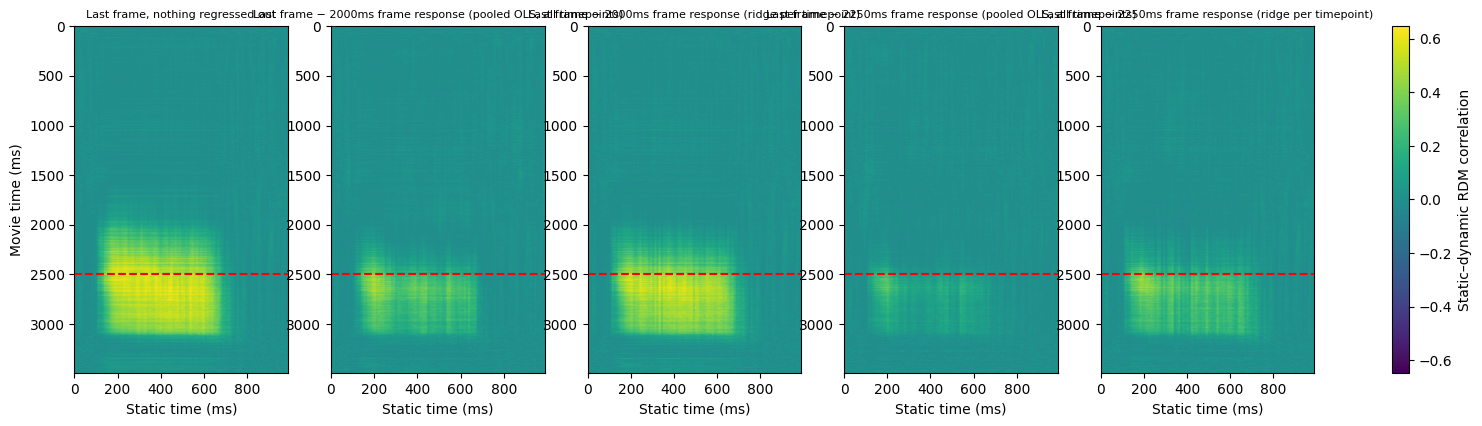

In [108]:
# Full static x dynamic RDM similarity, as in summary_figs_report cell 42.
residual_keys = [key for key in static_versions if key[0] != 'raw']
full_similarity = {
    key: cross_temporal_similarity(
        dynamic_rdms,
        compute_rdm_timeseries(static_ts.get_array(), cfg.signal_RDM_metric),
        metric=cfg.RSA_metric,
    )
    for key, static_ts in static_versions.items()
}
similarity_limit = np.nanmax(np.abs(np.stack(list(full_similarity.values()))))

fig, axes = plt.subplots(1, len(full_similarity), figsize=(4 * len(full_similarity), 4.5))
for axis, (key, similarity) in zip(axes, full_similarity.items()):
    image = axis.imshow(
        similarity, origin='upper', aspect='auto', cmap='viridis',
        vmin=-similarity_limit, vmax=similarity_limit,
        extent=(static_time_ms[0], static_time_ms[-1],
                dynamic_time_ms[-1], dynamic_time_ms[0]),
    )
    axis.axhline(cfg.last_frame_onset_ms, linestyle='--', color='red')
    axis.set(xlabel='Static time (ms)')
    axis.set_title(version_title(key), fontsize=8)
# end for axis, (key, similarity)
axes[0].set_ylabel('Movie time (ms)')
fig.colorbar(image, ax=axes, label='Static–dynamic RDM correlation')

## Static windows as layers

Each window's time-averaged static pattern gives one model RDM; its correlation with the movie RDM at every movie time is that "layer's" timecourse. Latencies are relative to the last-frame onset; the depth score is the Spearman rho between window index and latency.

For raw / pooled / timepoint, the (residual) timecourse is averaged inside each window. For window, the residual patterns come directly from the window-to-window regression.

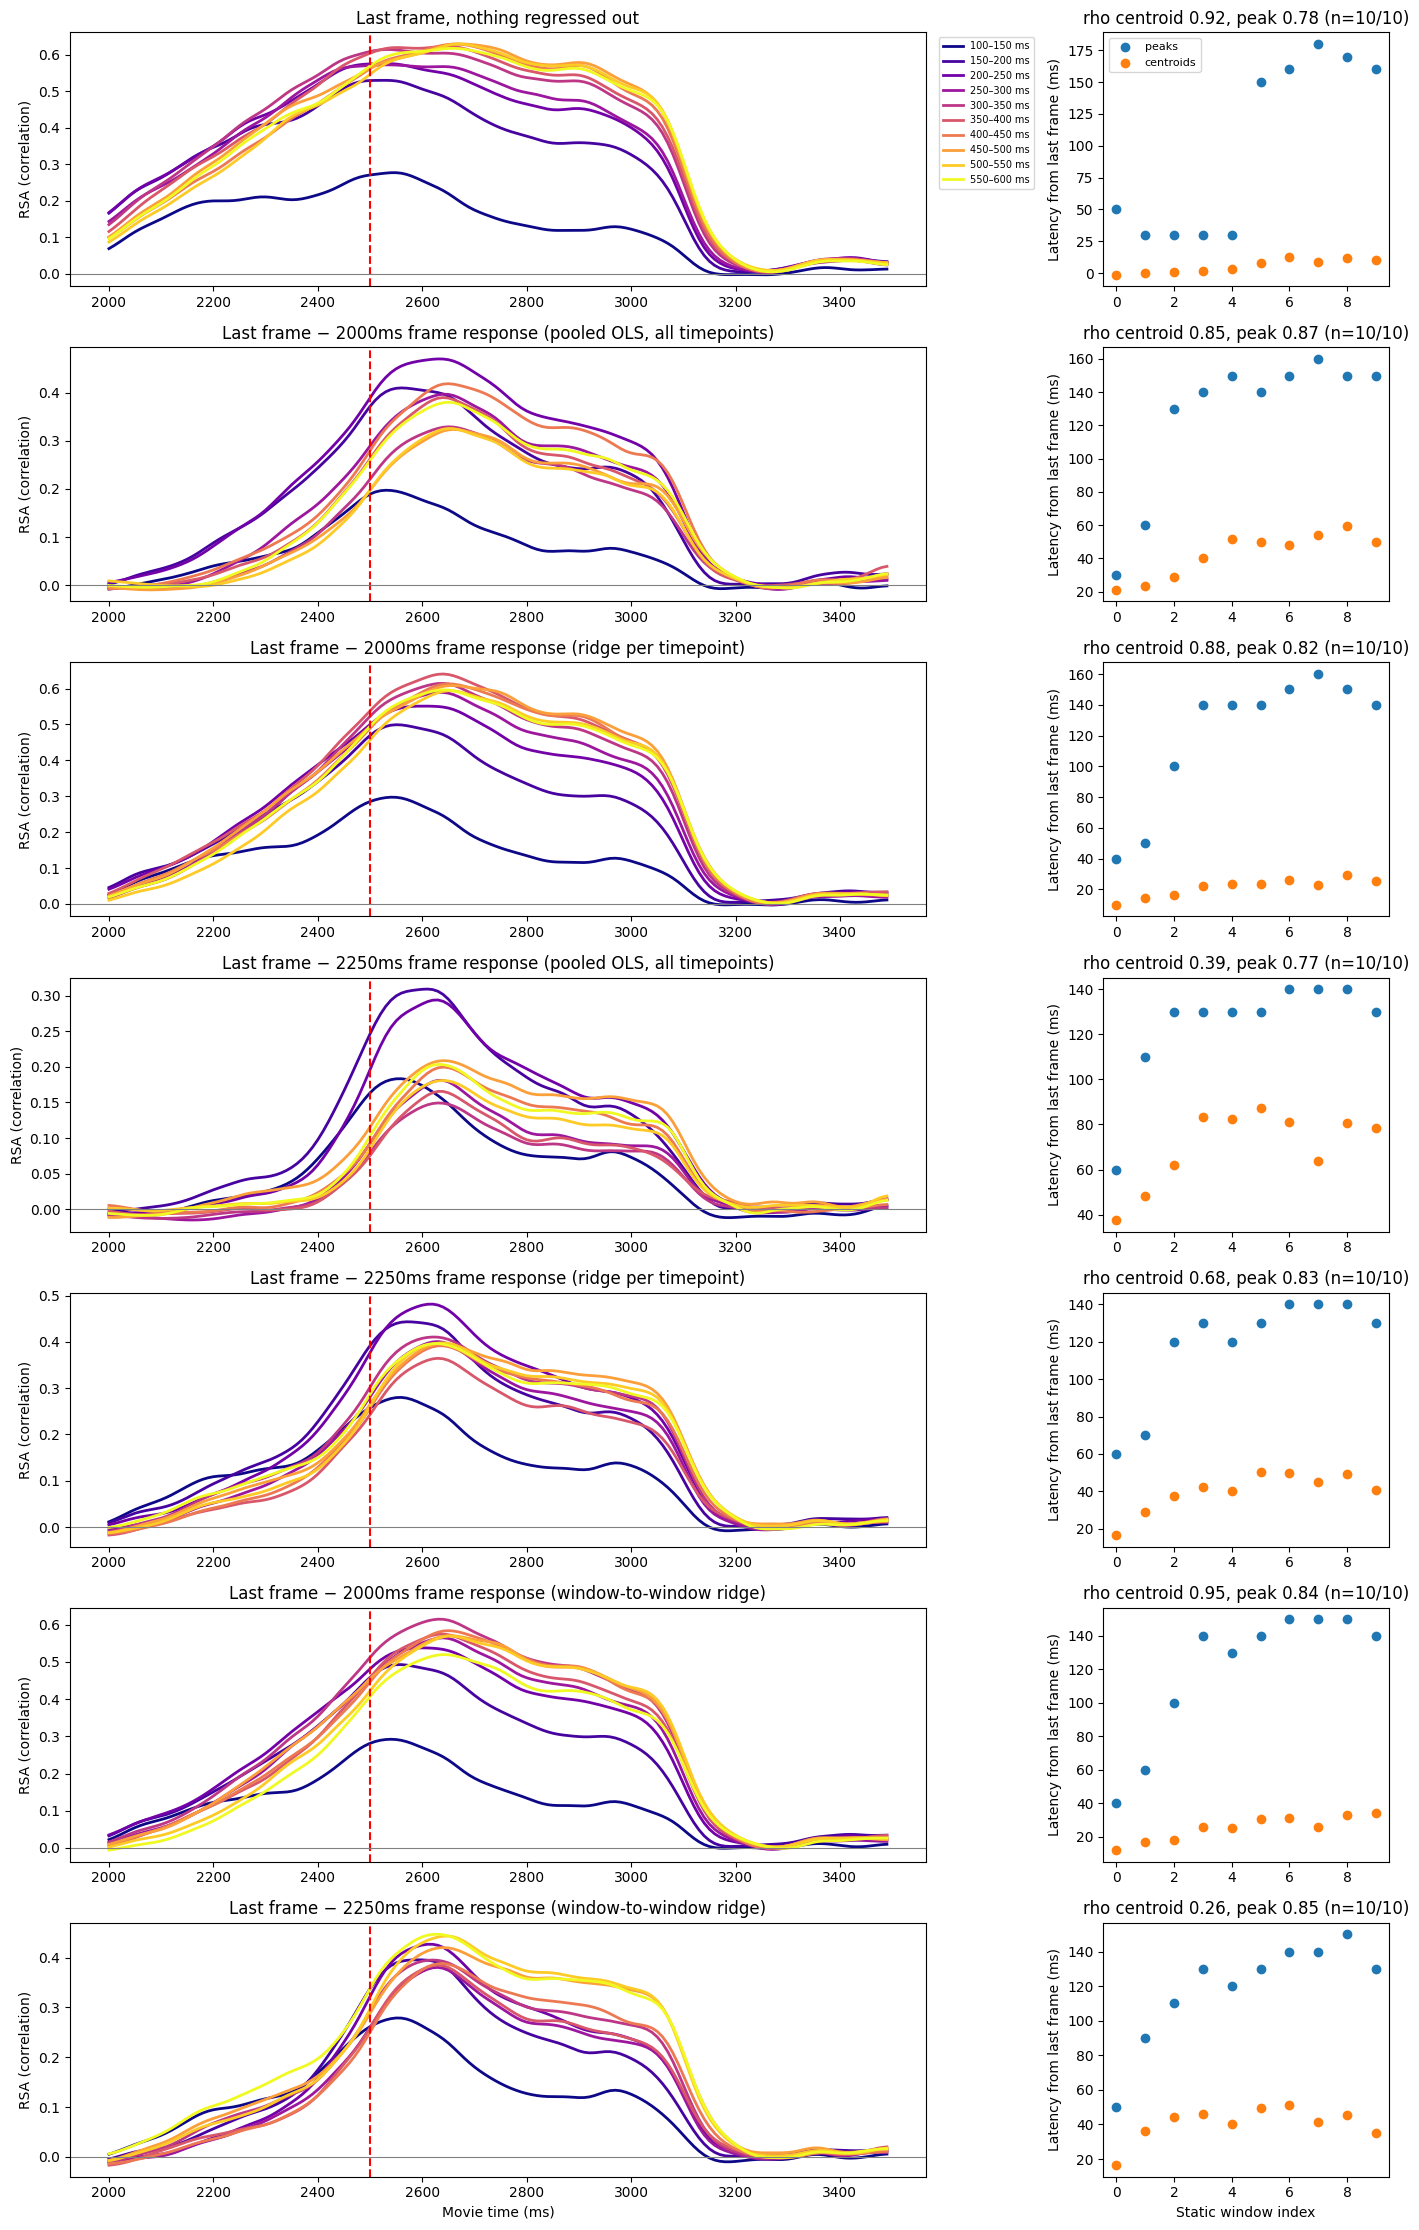

In [109]:
window_colors = plt.cm.plasma(np.linspace(0, 1, len(windows_ms)))
window_labels = [f'{start:g}–{end:g} ms' for start, end in windows_ms]
window_depths = np.linspace(0, 1, len(windows_ms))
plot_mask = (
    (dynamic_time_ms >= cfg.plot_window_ms[0])
    & (dynamic_time_ms < cfg.plot_window_ms[1])
)

# channels x windows x stimuli patterns for every static version.
version_patterns = {
    key: window_patterns(static_ts, windows_ms)
    for key, static_ts in static_versions.items()
}
window_variance_explained = {}
window_alphas = {}
for delayed_condition in cfg.residual_conditions:
    (
        version_patterns[('window', delayed_condition)],
        window_variance_explained[delayed_condition],
        window_alphas[delayed_condition],
    ) = window_static_regress_out(
        delayed_static_by_condition[delayed_condition], image_ts, windows_ms,
        regression_type=cfg.window_regression_type,
        alphas=cfg.window_alphas,
        cv_type=cfg.window_cv_type,
        n_splits=cfg.window_n_splits,
    )
# end for delayed_condition

window_results = {}
for key, patterns in version_patterns.items():
    # windows x movie time.
    similarity = window_model_timecourses(
        dynamic_rdms, patterns, cfg.signal_RDM_metric, cfg.RSA_metric,
    )
    smoothed, centroid_ms, peak_ms, peak_similarity = summarize_layer_timing(
        similarity, dynamic_time_ms, cfg.last_frame_onset_ms,
        cfg.timing_window_ms, cfg.timing_window_ms, cfg.smoothing,
        cfg.centroid_cutoff, cfg.peak_cutoff,
    )
    # Weak windows (peak not above peak_cutoff) lose their centroid too, so
    # depth_latency_score ignores them in both correlations (NaN is skipped).
    weak_windows = ~(peak_similarity > cfg.peak_cutoff)
    centroid_ms[weak_windows] = np.nan
    peak_ms[weak_windows] = np.nan
    window_results[key] = {
        'smoothed': smoothed, 'centroid_ms': centroid_ms, 'peak_ms': peak_ms,
        'centroid_score': depth_latency_score(window_depths, centroid_ms),
        'peak_score': depth_latency_score(window_depths, peak_ms),
        'peak_similarity': peak_similarity,
    }
# end for key, static_ts

# One row per static version: timecourses (left) and latencies (right).
fig, axes = plt.subplots(
    len(window_results), 2, figsize=(14, 3.2 * len(window_results)),
    gridspec_kw={'width_ratios': [3, 1]}, squeeze=False,
)
for row, (key, result) in enumerate(window_results.items()):
    for window_index, curve in enumerate(result['smoothed']):
        axes[row, 0].plot(
            dynamic_time_ms[plot_mask], curve[plot_mask],
            color=window_colors[window_index], linewidth=cfg.linewidth,
            label=window_labels[window_index],
        )
    # end for window_index, curve
    axes[row, 0].axvline(cfg.last_frame_onset_ms, color='red', linestyle='--')
    axes[row, 0].axhline(0, color='grey', linewidth=0.8)
    axes[row, 0].set(title=version_title(key), ylabel=f'RSA ({cfg.RSA_metric})')

    window_indices = np.arange(len(windows_ms))
    axes[row, 1].scatter(window_indices, result['peak_ms'], label='peaks')
    axes[row, 1].scatter(window_indices, result['centroid_ms'], label='centroids')
    axes[row, 1].set(
        ylabel='Latency from last frame (ms)',
        title=(f"rho centroid {result['centroid_score']['rho']:.2f}, "
               f"peak {result['peak_score']['rho']:.2f} "
               f"(n={result['peak_score']['n_layers']}/{len(windows_ms)})"),
    )
# end for row, (key, result)
axes[0, 0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
axes[0, 1].legend(fontsize=8)
axes[-1, 0].set_xlabel('Movie time (ms)')
axes[-1, 1].set_xlabel('Static window index')
fig.tight_layout()

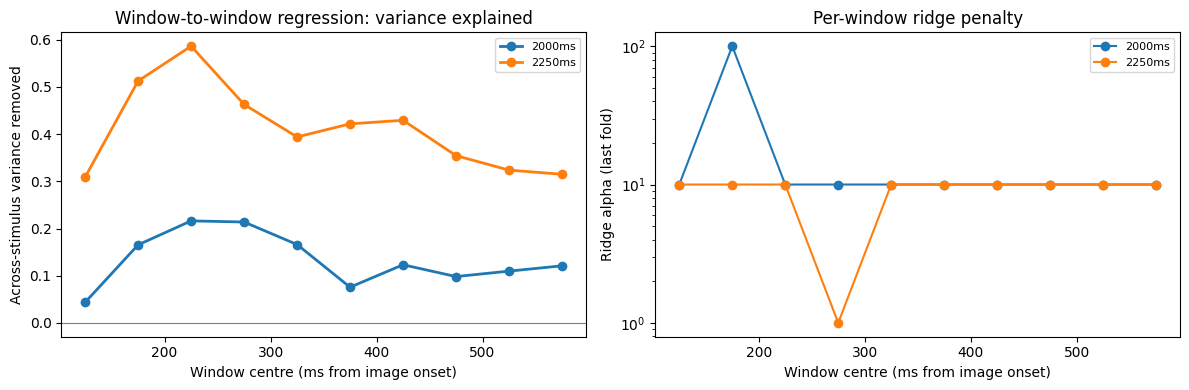

In [110]:
# How much of each last-frame window pattern the earlier window pattern explains.
window_centers_ms = [np.mean(window) for window in windows_ms]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for delayed_condition in cfg.residual_conditions:
    axes[0].plot(
        window_centers_ms, window_variance_explained[delayed_condition],
        marker='o', label=delayed_condition, linewidth=cfg.linewidth,
    )
    axes[1].semilogy(
        window_centers_ms, window_alphas[delayed_condition], marker='o',
        label=delayed_condition,
    )
# end for delayed_condition
axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].set(
    xlabel='Window centre (ms from image onset)',
    ylabel='Across-stimulus variance removed',
    title='Window-to-window regression: variance explained',
)
axes[1].set(
    xlabel='Window centre (ms from image onset)', ylabel='Ridge alpha (last fold)',
    title='Per-window ridge penalty',
)
for axis in axes:
    axis.legend(fontsize=8)
# end for axis
fig.tight_layout()

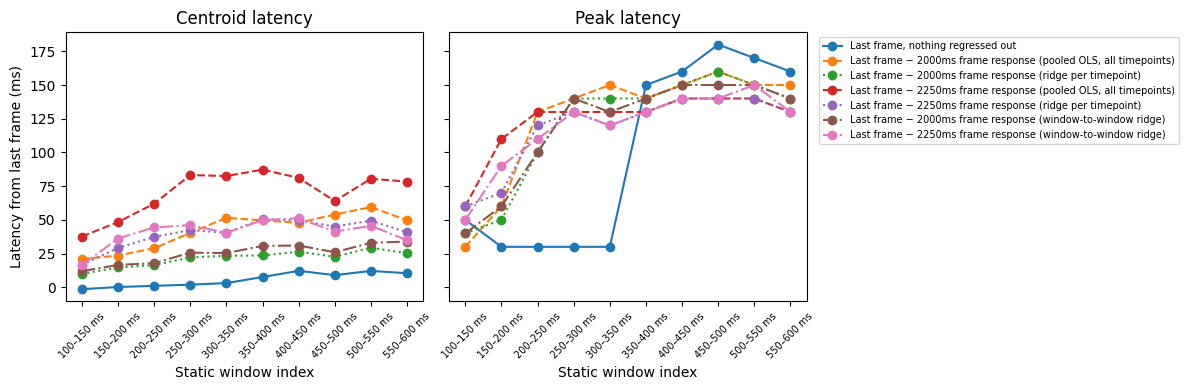

In [111]:
# Compact before/after comparison of the window-latency hierarchy.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for key, result in window_results.items():
    linestyle = {'raw': '-', 'pooled': '--', 'timepoint': ':', 'window': '-.'}[key[0]]
    for axis, latency_name in zip(axes, ('centroid_ms', 'peak_ms')):
        axis.plot(
            np.arange(len(windows_ms)), result[latency_name], marker='o',
            linestyle=linestyle, label=version_title(key),
        )
    # end for axis, latency_name
# end for key, result
for axis, title in zip(axes, ('Centroid latency', 'Peak latency')):
    axis.set(title=title, xlabel='Static window index')
    axis.set_xticks(np.arange(len(windows_ms)), window_labels, rotation=45, fontsize=7)
# end for axis, title
axes[0].set_ylabel('Latency from last frame (ms)')
axes[1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()